# LangGraph — Basic Chatbot

এই notebook-এ **LangGraph** দিয়ে একটা basic chatbot তৈরি করা হবে — weather tool সহ।

## LangGraph কী?

LangGraph হলো LangChain-এর একটা framework যেটা AI workflow-কে **directed graph** হিসেবে model করে।

```
LCEL Agent (linear):
  Input ──► Chain ──► Output

LangGraph (graph with cycles):
  START ──► [chatbot] ──► [tools] ──► [chatbot] ──► END
                  ↑           │
                  └───────────┘    (loop possible!)
```

| Feature | LCEL/create_agent | LangGraph |
|---|---|---|
| Structure | Linear chain | Directed graph (cycle সম্ভব) |
| State | নেই | TypedDict — সব node share করে |
| Control flow | Fixed | Conditional edges দিয়ে custom |
| Visualization | ❌ | ✅ Built-in draw_mermaid_png() |
| Memory | Middleware | InMemorySaver / checkpointer |

**এই notebook-এ:**
- LangGraph-এর ৩টি মূল concept: **State, Node, Edge**
- `StateGraph` + `ToolNode` দিয়ে chatbot তৈরি
- Graph visualization (ASCII + PNG)
- Weather tool integration
- Memory সহ multi-turn conversation

---
## LangGraph-এর ৩টি মূল Concept

### ১. State (অবস্থা)

State হলো graph-এর **shared memory** — সব node এটা পড়তে এবং update করতে পারে।

```python
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]
    #         ↑                 ↑
    #   message list      reducer function
    #                     (নতুন msg পুরনোটার সাথে merge করে)
```

**`add_messages` reducer কী করে:**

```
State আগে : messages = [HumanMessage("হ্যালো")]
Node return: messages = [AIMessage("হ্যালো! আমি AI")]
State পরে : messages = [HumanMessage("হ্যালো"), AIMessage("হ্যালো! আমি AI")]
```

মানে, state replace হয় না — নতুন message list-এ **append** হয়।

---

### ২. Node (কার্যকলাপ)

Node হলো graph-এর **processing unit** — একটা Python function যেটা:
- **Input:** State নেয়
- **কাজ:** LLM call, tool execute, logic — যা-ই হোক
- **Output:** State-এর একটা partial update return করে

```python
def chatbot(state: State):
    response = llm_with_tools.invoke(state["messages"])  # LLM call
    return {"messages": [response]}                       # partial update
```

**Node-এর ধরন:**

| Node | কাজ | কে লেখে |
|---|---|---|
| Custom node | LLM call, business logic | আমরা |
| `ToolNode` | Tool execution (auto) | LangGraph prebuilt |

---

### ৩. Edge (সংযোগ)

Edge node-গুলোকে **connect** করে — কোন node থেকে কোন node-এ যাবে সেটা define করে।

**Edge-এর ধরন:**

| Edge | কী করে | Code |
|---|---|---|
| Normal edge | সবসময় পরের node-এ যায় | `graph.add_edge("a", "b")` |
| Conditional edge | condition দেখে destination decide করে | `graph.add_conditional_edges(...)` |
| START edge | Graph-এ প্রবেশের পথ | `graph.add_edge(START, "chatbot")` |
| END | Graph শেষ করে | condition function থেকে `END` return |

**এই notebook-এর conditional flow:**

```
chatbot node output
    │
    ├── tool_calls আছে? → YES → tools node → chatbot node (loop)
    │
    └── tool_calls নেই? → NO  → END
```

---
### Step 1 — Environment Setup

**কী হচ্ছে:** `.env` file থেকে `ANTHROPIC_API_KEY` load করা হচ্ছে।

**কেন:** API key কখনো code-এ লেখা যাবে না।

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
print("ANTHROPIC_API_KEY:", bool(ANTHROPIC_API_KEY))

ANTHROPIC_API_KEY: True


---
### Step 2 — Weather Tool তৈরি

**কী হচ্ছে:** একটা `get_weather` tool তৈরি করা হচ্ছে যেটা chatbot ব্যবহার করতে পারবে।

**কেন tool দরকার:** LLM নিজে real-time data জানে না — tool দিয়ে external data নিয়ে আসে।

**`@tool` decorator:**
- Function-কে LangChain-compatible tool-এ convert করে
- Docstring → tool description হয় (LLM এটা পড়ে কখন call করবে বোঝে)
- Type hints → input schema হয়

In [2]:
from langchain_core.tools import tool

weather_db = {
    "dhaka":     {"temperature": "34°C", "condition": "Sunny",         "humidity": "72%", "wind_speed": "10 km/h", "feels_like": "38°C"},
    "chittagong":{"temperature": "32°C", "condition": "Partly Cloudy", "humidity": "78%", "wind_speed": "14 km/h", "feels_like": "36°C"},
    "london":    {"temperature": "17°C", "condition": "Overcast",      "humidity": "85%", "wind_speed": "20 km/h", "feels_like": "15°C"},
    "new york":  {"temperature": "22°C", "condition": "Clear",         "humidity": "55%", "wind_speed": "15 km/h", "feels_like": "21°C"},
}

@tool
def get_weather(city: str) -> str:
    """Return current weather for a given city."""
    key = city.lower().strip()
    if key not in weather_db:
        return f"No weather data for '{city}'. Available cities: {', '.join(weather_db.keys())}"
    w = weather_db[key]
    return (
        f"Weather in {city.title()}:\n"
        f"  Temperature : {w['temperature']} (feels like {w['feels_like']})\n"
        f"  Condition   : {w['condition']}\n"
        f"  Humidity    : {w['humidity']}\n"
        f"  Wind Speed  : {w['wind_speed']}"
    )

tools = [get_weather]
print("Tool name       :", get_weather.name)
print("Tool description:", get_weather.description)
print("Input schema    :", get_weather.args)

Tool name       : get_weather
Tool description: Return current weather for a given city.
Input schema    : {'city': {'title': 'City', 'type': 'string'}}


---
### Step 3 — State এবং LLM তৈরি

**State কেন TypedDict:**
- TypedDict type-safe — ভুল key দিলে IDE ধরবে
- LangGraph state-এ `Annotated` দিয়ে **reducer** specify করা যায়
- `add_messages` reducer নিশ্চিত করে message list replace না হয়ে append হয়

**`bind_tools` কেন:**
- LLM-কে জানিয়ে দেয় কোন tools সে call করতে পারবে
- LLM তখন response-এ `tool_calls` field include করতে পারে
- Without `bind_tools` → LLM tool call করতে পারবে না

In [3]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_anthropic import ChatAnthropic

# ── State definition ──
class State(TypedDict):
    messages: Annotated[list, add_messages]
    # add_messages reducer: নতুন msg পুরনোটার সাথে append করে

# ── LLM with tools bound ──
llm = ChatAnthropic(
    model="claude-haiku-4-5-20251001",
    anthropic_api_key=ANTHROPIC_API_KEY,
)
llm_with_tools = llm.bind_tools(tools)

print("State fields    :", dict(State.__annotations__))
print("LLM model       :", llm.model)
print("Tools bound     :", [t.name for t in tools])

State fields    : {'messages': typing.Annotated[list, <function _add_messages_wrapper.<locals>._add_messages at 0x000001A097E4EDE0>]}
LLM model       : claude-haiku-4-5-20251001
Tools bound     : ['get_weather']


---
### Step 4 — Nodes তৈরি

**দুটো node তৈরি হবে:**

| Node | ধরন | কাজ |
|---|---|---|
| `chatbot` | Custom function | LLM call করে, tool call decide করে |
| `tools` | `ToolNode` (prebuilt) | Tool execute করে, ToolMessage তৈরি করে |

**`ToolNode` internally কীভাবে কাজ করে:**

```
State-এ messages[-1] দেখো
    ↓
messages[-1].tool_calls আছে কি?
    ↓
প্রতিটা tool_call-এর জন্য:
    tool_map[call["name"]].invoke(call["args"])
    ↓
ToolMessage তৈরি করে State-এ যোগ করো
```

আমরা manually লিখলে এটা হতো:

```python
def manual_tool_node(state: State):
    last_msg = state["messages"][-1]
    results = []
    for tc in last_msg.tool_calls:
        fn = tool_map[tc["name"]]
        result = fn.invoke(tc["args"])
        results.append(ToolMessage(content=result, tool_call_id=tc["id"]))
    return {"messages": results}
```

`ToolNode` এটাই internally করে — আমাদের লিখতে হয় না।

In [4]:
from langgraph.prebuilt import ToolNode

# ── Custom chatbot node ──
def chatbot(state: State):
    """LLM call করে, response return করে।"""
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

# ── Prebuilt ToolNode ──
tool_node = ToolNode(tools)

print("chatbot  : custom function node")
print("tool_node: ToolNode (prebuilt) with tools =", [t.name for t in tools])

chatbot  : custom function node
tool_node: ToolNode (prebuilt) with tools = ['get_weather']


---
### Step 5 — Graph তৈরি: Nodes ও Edges connect করা

**Graph-এর পুরো flow:**

```
START
  ↓
[chatbot] node  ←──────────────────────────────┐
  ↓                                              │
tools_condition (conditional edge)              │
  │                                              │
  ├── tool_calls আছে? ──► [tools] node ──────────┘
  │                         (ToolNode executes,
  │                          ToolMessage return)
  └── tool_calls নেই? ──► END
```

**`tools_condition` — LangGraph-এর built-in routing function:**

```python
from langgraph.prebuilt import tools_condition

# Internally এটা করে:
def tools_condition(state):
    last_msg = state["messages"][-1]
    if last_msg.tool_calls:    # tool call আছে?
        return "tools"         # → tools node
    return END                 # → graph শেষ
```

**`add_conditional_edges` parameter:**

```python
graph.add_conditional_edges(
    "chatbot",       # এই node থেকে
    tools_condition, # এই function দিয়ে destination decide
)
# default mapping: {"tools": "tools", END: END}
```

In [5]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition

# ── Graph builder তৈরি ──
graph_builder = StateGraph(State)

# ── Nodes যোগ করো ──
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", tool_node)

# ── Edges যোগ করো ──
graph_builder.add_edge(START, "chatbot")          # START → chatbot (entry point)

graph_builder.add_conditional_edges(              # chatbot → tools বা END
    "chatbot",
    tools_condition,
)

graph_builder.add_edge("tools", "chatbot")        # tools → chatbot (loop back)

# ── Graph compile করো (without memory) ──
graph = graph_builder.compile()

print("Graph compiled!")
print("Nodes:", list(graph.get_graph().nodes.keys()))
print("Edges:")
for edge in graph.get_graph().edges:
    print(f"  {edge[0]} → {edge[1]}")

Graph compiled!
Nodes: ['__start__', 'chatbot', 'tools', '__end__']
Edges:
  __start__ → chatbot
  chatbot → __end__
  chatbot → tools
  tools → chatbot


---
### Step 6 — Graph Visualization

**LangGraph graph দেখার উপায়:**

| Method | Output | Requirements |
|---|---|---|
| `draw_mermaid()` | Mermaid syntax string (text) | None (সবসময় কাজ করে) |
| `draw_mermaid_png()` | PNG image (Jupyter-এ দেখা যায়) | Internet (mermaid.ink) |

**কেন visualize দরকার:**
- Graph structure সহজে বোঝা যায়
- Edge/Node ঠিকমতো connect হয়েছে কিনা verify করা যায়
- Debugging-এ সাহায্য করে

In [8]:
# ── Mermaid syntax (text, no dependencies) ──
print("=" * 50)
print("Graph (Mermaid syntax)")
print("=" * 50)
print(graph.get_graph().draw_mermaid())

Graph (Mermaid syntax)
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	chatbot(chatbot)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> chatbot;
	chatbot -.-> __end__;
	chatbot -.-> tools;
	tools --> chatbot;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



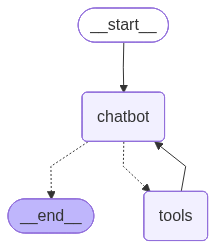

In [9]:
# ── PNG visualization (Jupyter notebook-এ দেখা যায়) ──
from IPython.display import Image, display

try:
    png_data = graph.get_graph().draw_mermaid_png()
    display(Image(png_data))
except Exception as e:
    print(f"PNG render skipped: {e}")
    print("উপরের ASCII graph দেখো।")

---
### Step 7 — Chatbot চালানো (Memory ছাড়া)

**একটা single invocation-এ কী হয়:**

```
invoke({messages: [HumanMessage("Dhaka-র আবহাওয়া?")]})
    ↓
START → [chatbot] node
    LLM দেখে → tool call দরকার → tool_calls=[get_weather("dhaka")]
    return: AIMessage with tool_calls
    ↓
tools_condition → "tools" (tool_calls আছে)
    ↓
[tools] node (ToolNode)
    get_weather("dhaka") চালায়
    return: ToolMessage("Weather in Dhaka: 34°C...")
    ↓
[chatbot] node (আবার)
    LLM: ToolMessage দেখে, user-friendly answer তৈরি করে
    return: AIMessage("ঢাকার আবহাওয়া: ৩৪°C...")
    ↓
tools_condition → END (tool_calls নেই)
    ↓
Final output!
```

In [7]:
from langchain_core.messages import HumanMessage

def chat(user_input: str) -> str:
    """Single-turn chat (memory ছাড়া)."""
    result = graph.invoke({"messages": [HumanMessage(content=user_input)]})
    last = result["messages"][-1]
    return last.content if isinstance(last.content, str) else str(last.content)

# ── Test 1: Weather query (tool use) ──
print("=" * 55)
print("Test 1: Weather Query (tool use)")
print("=" * 55)
q1 = "Dhaka-র আজকের আবহাওয়া কেমন?"
print("Human:", q1)
print("AI:", chat(q1))

# ── Test 2: No tool needed ──
print("\n" + "=" * 55)
print("Test 2: No tool needed")
print("=" * 55)
q2 = "তুমি কে? কী করতে পারো?"
print("Human:", q2)
print("AI:", chat(q2))

# ── Test 3: Multi-city comparison ──
print("\n" + "=" * 55)
print("Test 3: Multi-city (multiple tool calls)")
print("=" * 55)
q3 = "London এবং Dhaka-র আবহাওয়া তুলনা করো।"
print("Human:", q3)
print("AI:", chat(q3))

Test 1: Weather Query (tool use)
Human: Dhaka-র আজকের আবহাওয়া কেমন?
AI: ঢাকার আজকের আবহাওয়া:

- **তাপমাত্রা:** ৩৪°C (মনে হচ্ছে ৩৮°C)
- **আবহাওয়া:** রৌদ্রোজ্জ্বল
- **আর্দ্রতা:** ৭২%
- **বায়ুর গতি:** ১০ কিমি/ঘণ্টা

আজ ঢাকায় বেশ গরম এবং রৌদ্রোজ্জ্বল দিন আছে। বাইরে বের হলে প্রচুর পানি পান করুন এবং সূর্যের তীব্র তাপ থেকে বাঁচার চেষ্টা করুন।

Test 2: No tool needed
Human: তুমি কে? কী করতে পারো?
AI: আমি Claude, একজন AI সহায়ক। আমি আপনাকে বিভিন্ন কাজে সাহায্য করতে পারি:

**আমি যা করতে পারি:**

1. **প্রশ্নের উত্তর দেওয়া** - বিভিন্ন বিষয়ে তথ্য এবং ব্যাখ্যা প্রদান করা
2. **লেখা এবং সম্পাদনা** - গল্প, প্রবন্ধ, কোড, ইমেইল লেখা বা সম্পাদনা করা
3. **বিশ্লেষণ এবং গবেষণা** - তথ্য বিশ্লেষণ এবং জটিল সমস্যা সমাধান করা
4. **শিক্ষা এবং শেখা** - বিভিন্ন বিষয়ে শিক্ষামূলক সহায়তা প্রদান করা
5. **সৃজনশীল কাজ** - ধারণা তৈরি করা, ব্রেনস্টর্মিং করা
6. **আবহাওয়া তথ্য** - যেকোনো শহরের বর্তমান আবহাওয়া জানা

**আমার সীমাবদ্ধতা:**
- আমি রিয়েল-টাইম ইন্টারনেট অ্যাক্সেস করতে পারি না (শুধুমাত্র নির্দিষ্ট কয়েকটি 

---
### Step 8 — Memory সহ Chatbot (MemorySaver)

**Memory কেন দরকার:**

Memory ছাড়া প্রতিটা `invoke()` নতুন conversation শুরু করে — আগের কথা মনে থাকে না।

```
Memory ছাড়া:
  invoke("আমার নাম Nibras")   → OK
  invoke("আমার নাম কী?")     → "আমি জানি না" ← আগের turn মনে নেই!

Memory সহ (same thread_id):
  invoke("আমার নাম Nibras")   → OK
  invoke("আমার নাম কী?")     → "আপনার নাম Nibras" ← মনে আছে!
```

**`MemorySaver` (InMemorySaver) কীভাবে কাজ করে:**

```
Thread ID = "session-abc"
    ↓
প্রতিটা state change → checkpoint হিসেবে save হয়
    ↓
পরের invoke-এ → thread_id দিয়ে পুরনো state load হয়
    ↓
Conversation history intact থাকে
```

**Config:**

```python
config = {"configurable": {"thread_id": "unique-session-id"}}
# ↑ একই thread_id → একই conversation
# ↑ নতুন thread_id → নতুন conversation
```

In [11]:
import uuid
from langgraph.checkpoint.memory import MemorySaver

# ── Memory সহ graph compile ──
memory = MemorySaver()
graph_with_memory = graph_builder.compile(checkpointer=memory)

# ── নতুন session তৈরি ──
session_id = str(uuid.uuid4())
config = {"configurable": {"thread_id": session_id}}

print(f"Session ID: {session_id[:8]}...")
print()

# ── Multi-turn conversation ──
turns = [
    "আমার নাম Nibras। আমি বাংলাদেশ থেকে।",
    "Dhaka-র আবহাওয়া কেমন?",
    "London-এর সাথে তুলনা করো।",
    "আমার নাম কী বলেছিলাম মনে আছে?",   # memory test!
]

for i, msg in enumerate(turns, 1):
    print(f"{'─'*55}")
    print(f"Turn {i}")
    print(f"{'─'*55}")
    print(f"Human: {msg}")
    result = graph_with_memory.invoke(
        {"messages": [HumanMessage(content=msg)]},
        config=config,
    )
    ai_response = result["messages"][-1].content
    preview = ai_response if isinstance(ai_response, str) else str(ai_response)
    print(f"AI: {preview[:250]}{'...' if len(preview) > 250 else ''}")
    print()

# ── State inspect ──
print("=" * 55)
print("Final State (message history)")
print("=" * 55)
final_state = graph_with_memory.get_state(config)
msgs = final_state.values.get("messages", [])
print(f"Total messages in state: {len(msgs)}")
print()
for m in msgs:
    role = type(m).__name__
    content = str(m.content)[:70].replace('\n', ' ')
    print(f"  [{role}] {content}")

Session ID: dd3f9156...

───────────────────────────────────────────────────────
Turn 1
───────────────────────────────────────────────────────
Human: আমার নাম Nibras। আমি বাংলাদেশ থেকে।
AI: আপনাকে স্বাগতম, Nibras! বাংলাদেশ থেকে আপনার সাথে কথা বলতে পেরে আমি আনন্দিত। 😊

আমি আপনাকে কীভাবে সাহায্য করতে পারি? আপনার কোনো প্রশ্ন বা যোগাযোগের প্রয়োজন আছে? আমি বিভিন্ন বিষয়ে আপনাকে সহায়তা করতে প্রস্তুত।

───────────────────────────────────────────────────────
Turn 2
───────────────────────────────────────────────────────
Human: Dhaka-র আবহাওয়া কেমন?
AI: ঢাকার বর্তমান আবহাওয়া এখানে আছে:

**🌡️ তাপমাত্রা:** ৩৪°C (অনুভূত তাপমাত্রা ৩৮°C)
**☀️ আবহাওয়া:** রৌদ্রোজ্জ্বল
**💧 আর্দ্রতা:** ৭২%
**💨 বায়ুর গতি:** ১০ কিমি/ঘণ্টা

আজ ঢাকায় বেশ গরম এবং আর্দ্র আবহাওয়া রয়েছে। বাইরে যেতে হলে প্রচুর পানি পান করুন এবং...

───────────────────────────────────────────────────────
Turn 3
───────────────────────────────────────────────────────
Human: London-এর সাথে তুলনা করো।
AI: ঢাকা এবং লন্ডনের আবহাওয়ার তুলনা:


---
### Step 9 — Streaming (Node-by-node output)

**`stream()` বনাম `invoke()`:**

| Method | Output | Use case |
|---|---|---|
| `invoke()` | পুরো response একসাথে | Simple queries |
| `stream()` | প্রতিটা node-এর output আলাদা | Debugging, real-time UI |

**Stream mode:**

| Mode | মানে |
|---|---|
| `"values"` | প্রতিটা step-এ পুরো state দেয় |
| `"updates"` | শুধু নতুন পরিবর্তন দেয় (lightweight) |

**Streaming-এ কী দেখা যায়:**

```
[chatbot] AIMessage → tool_calls = ["get_weather"]
[tools]   ToolMessage → "Weather in Chittagong: ..."
[chatbot] AIMessage → "চট্টগ্রামের আবহাওয়া: ..."
```

In [ ]:
# ── Stream দিয়ে node-by-node দেখো ──
config_stream = {"configurable": {"thread_id": str(uuid.uuid4())}}

print("=" * 55)
print("Streaming: updates mode")
print("=" * 55)
print("Human: Chittagong-এর আবহাওয়া বলো এবং ভ্রমণের পরামর্শ দাও।")
print()

for event in graph_with_memory.stream(
    {"messages": [HumanMessage(content="Chittagong-এর আবহাওয়া বলো এবং ভ্রমণের পরামর্শ দাও।")]},
    config=config_stream,
    stream_mode="updates",
):
    for node_name, node_output in event.items():
        msgs = node_output.get("messages", [])
        for msg in msgs:
            role = type(msg).__name__
            if hasattr(msg, "tool_calls") and msg.tool_calls:
                tool_names = [tc["name"] for tc in msg.tool_calls]
                print(f"  [{node_name}] {role} → tool_calls: {tool_names}")
            elif hasattr(msg, "name") and msg.name:
                content_preview = str(msg.content)[:80].replace('\n', ' ')
                print(f"  [{node_name}] ToolMessage (tool={msg.name}): {content_preview}")
            else:
                content_preview = str(msg.content)[:150].replace('\n', ' ')
                print(f"  [{node_name}] {role}: {content_preview}{'...' if len(str(msg.content)) > 150 else ''}")

---
### Step 10 — Graph Introspection (State দেখা)

**`get_state()` দিয়ে যা দেখা যায়:**

| Attribute | মানে |
|---|---|
| `state.values` | বর্তমান state-এর সব values |
| `state.next` | পরবর্তী কোন node execute হবে |
| `state.metadata` | Step count, run ID |
| `state.config` | Thread ID ইত্যাদি |

In [ ]:
# ── Graph state introspection ──
print("=" * 55)
print("Graph State Introspection")
print("=" * 55)

state = graph_with_memory.get_state(config)

print("Messages in state:", len(state.values.get("messages", [])))
print("Next nodes       :", state.next)
print("Step count       :", state.metadata.get("step", "N/A"))
print()

print("Message breakdown:")
for m in state.values.get("messages", []):
    role = type(m).__name__
    preview = str(m.content)[:60].replace('\n', ' ')
    extra = ""
    if hasattr(m, "tool_calls") and m.tool_calls:
        extra = f" [tool_calls: {[tc['name'] for tc in m.tool_calls]}]"
    elif hasattr(m, "name") and m.name:
        extra = f" [tool: {m.name}]"
    print(f"  {role:<20} {preview}{extra}")

# ── State history ──
print()
print("=" * 55)
print("State History (checkpoints)")
print("=" * 55)
history = list(graph_with_memory.get_state_history(config))
print(f"Total checkpoints: {len(history)}")
for i, checkpoint in enumerate(history[:3]):
    msg_count = len(checkpoint.values.get("messages", []))
    print(f"  Checkpoint {i+1}: {msg_count} messages, next={checkpoint.next}")

---
## সারসংক্ষেপ

### LangGraph-এর ৩টি মূল Concept

| Concept | কী | Code |
|---|---|---|
| **State** | Shared data across nodes | `class State(TypedDict): messages: Annotated[list, add_messages]` |
| **Node** | Processing unit (function) | `def chatbot(state): return {"messages": [...]}` |
| **Edge** | Connection between nodes | `graph.add_edge(A, B)` বা `add_conditional_edges(...)` |

### Full Graph Flow এই Notebook-এ

```
START
  ↓
[chatbot] node          ← LLM call করে
  ↓
tools_condition          (conditional edge)
  ├── tool_calls আছে ──► [tools] node  ← ToolNode execute করে
  │                           ↓
  │                       [chatbot]   ← result নিয়ে আবার LLM
  │                           ↓
  └── tool_calls নেই ──► END
```

### Key Classes এবং Functions

| Class / Function | Package | কাজ |
|---|---|---|
| `StateGraph` | `langgraph.graph` | Graph builder |
| `START`, `END` | `langgraph.graph` | Graph entry/exit markers |
| `ToolNode` | `langgraph.prebuilt` | Auto tool execution |
| `tools_condition` | `langgraph.prebuilt` | Routing — tools বা END |
| `MemorySaver` | `langgraph.checkpoint.memory` | In-memory checkpointing |
| `add_messages` | `langgraph.graph.message` | State reducer — messages append করে |

### Quick Recipe

```python
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict

class State(TypedDict):
    messages: Annotated[list, add_messages]

builder = StateGraph(State)
builder.add_node("chatbot", chatbot)       # custom node
builder.add_node("tools", ToolNode(tools)) # prebuilt node
builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)
builder.add_edge("tools", "chatbot")

graph = builder.compile(checkpointer=MemorySaver())
```

### পরবর্তী Notebook-এ
- **Human-in-the-loop** — graph-এ `interrupt` দিয়ে মানুষের approval
- **Parallel nodes** — একাধিক node একসাথে চালানো (`Send`)
- **Custom state** — messages ছাড়াও custom fields রাখা

---
## Bonus — ReAct Agent Architecture

**ReAct কী?**

ReAct = **Re**asoning + **Act**ing

ReAct হলো একটা agent pattern যেখানে LLM পর্যায়ক্রমে চিন্তা করে এবং কাজ করে:

```
Human: "Dhaka-র আবহাওয়া বলো এবং পরামর্শ দাও"
         ↓
[Reason]  "weather data আনতে হবে"
         ↓
[Act]     get_weather("dhaka") ← tool call
         ↓
[Observe] "34°C, Sunny, humidity 72%..."
         ↓
[Reason]  "এখন আমি পরামর্শ দিতে পারি"
         ↓
[Answer]  "ঢাকায় বেশ গরম — পানি পান করুন, ছাতা নিন"
```

**এই loop-টাই ReAct:** Reason → Act → Observe → Reason → ... → Final Answer

---

### Manual Graph বনাম create_agent

| | Manual Graph (এই notebook-এ) | `create_agent` |
|---|---|---|
| State | TypedDict manually define | Built-in |
| Nodes | `add_node()` manually | Auto |
| Edges | `add_edge()` manually | Auto |
| System prompt | manually inject | `prompt` parameter |
| Code পরিমাণ | ~20 lines | ~3 lines |
| Customization | সম্পূর্ণ নিয়ন্ত্রণ | সীমিত |

**কখন কোনটা:**
- Simple agent → `create_agent` (quick, clean)
- Custom logic / branching / parallel nodes → Manual `StateGraph`

**Internal structure একই:**

```
START → [agent] → tools_condition → [tools] → [agent] → ... → END
```

> ⚠️ `from langgraph.prebuilt import create_react_agent` → **deprecated**  
> ✅ `from langchain.agents import create_agent` → **latest**

### Step 1 — create_agent তৈরি

**`create_agent` parameters:**

| Parameter | কাজ |
|---|---|
| `model` | LLM — `bind_tools()` ছাড়াই দাও, function নিজে করে |
| `tools` | Tool list |
| `system_prompt` | System prompt — plain **string** (not `SystemMessage`) |
| `checkpointer` | Memory — `MemorySaver()` দিলে multi-turn কাজ করে |

> **Note:** `create_react_agent` from `langgraph.prebuilt` deprecated হয়ে গেছে।  
> Latest API: `from langchain.agents import create_agent`

In [15]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import MemorySaver

SYSTEM_PROMPT = """তুমি একজন helpful weather assistant।
তোমার কাছে get_weather tool আছে — যেকোনো শহরের আবহাওয়া জানতে এটা ব্যবহার করো।
সবসময় বাংলায় উত্তর দাও।
Weather data দেখে practical পরামর্শ দাও (কী পরবে, কী করবে ইত্যাদি)।"""

# ── একটা function call-এই পুরো ReAct agent ──
react_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=SYSTEM_PROMPT,   # ← plain string (not SystemMessage)
    checkpointer=MemorySaver(),
)

print("ReAct agent তৈরি হয়েছে!")
print("Type    :", type(react_agent).__name__)
print("Nodes   :", list(react_agent.get_graph().nodes.keys()))
print("Edges   :")
for edge in react_agent.get_graph().edges:
    print(f"  {edge[0]} → {edge[1]}")

ReAct agent তৈরি হয়েছে!
Type    : CompiledStateGraph
Nodes   : ['__start__', 'model', 'tools', '__end__']
Edges   :
  __start__ → model
  model → __end__
  model → tools
  tools → model


### Step 2 — ReAct Graph Visualization

`create_react_agent` internally যে graph তৈরি করে সেটা দেখো — আমাদের manual graph-এর মতোই।

=== ReAct Agent Graph (Mermaid) ===
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	model(model)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> model;
	model -.-> __end__;
	model -.-> tools;
	tools -.-> model;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



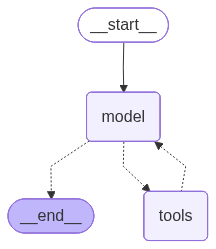

In [16]:
from IPython.display import Image, display

# ── Mermaid syntax (text) ──
print("=== ReAct Agent Graph (Mermaid) ===")
print(react_agent.get_graph().draw_mermaid())

# ── PNG (Jupyter-এ render হয়) ──
try:
    display(Image(react_agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"PNG render skipped: {e}")

### Step 3 — ReAct Agent চালানো

**Streaming দিয়ে ReAct loop দেখো:**

প্রতিটা step আলাদাভাবে দেখা যাবে — Reason → Act → Observe → Reason → Answer।

In [17]:
import uuid
from langchain_core.messages import HumanMessage

session_id = str(uuid.uuid4())
config = {"configurable": {"thread_id": session_id}}

query = "Dhaka-র আবহাওয়া বলো এবং কী কী সতর্কতা নেওয়া উচিত জানাও।"

print("=" * 58)
print("ReAct Loop — step-by-step (stream_mode='updates')")
print("=" * 58)
print(f"Human: {query}\n")

step = 0
for event in react_agent.stream(
    {"messages": [HumanMessage(content=query)]},
    config=config,
    stream_mode="updates",
):
    for node_name, node_output in event.items():
        step += 1
        msgs = node_output.get("messages", [])
        for msg in msgs:
            role = type(msg).__name__
            if hasattr(msg, "tool_calls") and msg.tool_calls:
                tool_names = [tc["name"] for tc in msg.tool_calls]
                print(f"  Step {step} [{node_name}] REASON → ACT : tool_calls = {tool_names}")
            elif hasattr(msg, "name") and msg.name:
                content_preview = str(msg.content)[:80].replace("\n", " ")
                print(f"  Step {step} [{node_name}] OBSERVE      : {content_preview}")
            else:
                content_preview = str(msg.content)[:120].replace("\n", " ")
                print(f"  Step {step} [{node_name}] FINAL ANSWER : {content_preview}{'...' if len(str(msg.content)) > 120 else ''}")

ReAct Loop — step-by-step (stream_mode='updates')
Human: Dhaka-র আবহাওয়া বলো এবং কী কী সতর্কতা নেওয়া উচিত জানাও।

  Step 1 [model] REASON → ACT : tool_calls = ['get_weather']
  Step 2 [tools] OBSERVE      : Weather in Dhaka:   Temperature : 34°C (feels like 38°C)   Condition   : Sunny  
  Step 3 [model] FINAL ANSWER : ঢাকার আবহাওয়া সম্পর্কে বিস্তারিত তথ্য:  **বর্তমান আবহাওয়া:** - 🌡️ তাপমাত্রা: ৩৪°C (মনে হচ্ছে ৩৮°C) - ☀️ অবস্থা: রৌদ্রো...


In [18]:
# ── Multi-turn conversation (memory test) ──
print("=" * 58)
print("Multi-turn + Memory Test")
print("=" * 58)

turns = [
    "New York-এ এখন কী আবহাওয়া?",
    "Dhaka-র সাথে তুলনা করো।",
    "কোন শহরে বেড়াতে যাওয়া ভালো এখন?",   # memory: আগের দুই turn মনে রেখে answer
]

for i, q in enumerate(turns, 1):
    print(f"\n{'─' * 58}")
    print(f"Turn {i} | Human: {q}")
    print(f"{'─' * 58}")
    result = react_agent.invoke(
        {"messages": [HumanMessage(content=q)]},
        config=config,
    )
    ai_content = result["messages"][-1].content
    if not isinstance(ai_content, str):
        ai_content = str(ai_content)
    print(f"AI: {ai_content[:350]}{'...' if len(ai_content) > 350 else ''}")

Multi-turn + Memory Test

──────────────────────────────────────────────────────────
Turn 1 | Human: New York-এ এখন কী আবহাওয়া?
──────────────────────────────────────────────────────────
AI: **নিউয়ইয়র্কের আবহাওয়া:**

- 🌡️ তাপমাত্রা: ২২°C (মনে হচ্ছে ২১°C)
- ☀️ অবস্থা: পরিষ্কার আকাশ
- 💧 আর্দ্রতা: ৫৫%
- 💨 বাতাসের গতি: ১৫ কিমি/ঘণ্টা

**পরামর্শ:**

1. **পোশাক:**
   - হালকা জ্যাকেট বা সোয়েটার নিয়ে যান
   - বাতাস একটু বেশি, তাই বন্ধ পোশাক ভালো

2. **বাইরের কাজকর্ম:**
   - অত্যন্ত আনুকুল আবহাওয়া!
   - হাঁটাহাঁটি, পার্কে যাওয়া বা বাইরের ...

──────────────────────────────────────────────────────────
Turn 2 | Human: Dhaka-র সাথে তুলনা করো।
──────────────────────────────────────────────────────────
AI: **ঢাকা এবং নিউয়ইয়র্কের আবহাওয়া তুলনা:**

| বৈশিষ্ট্য | ঢাকা | নিউয়ইয়র্ক | পার্থক্য |
|----------|------|-----------|---------|
| **তাপমাত্রা** | ৩৪°C | ২২°C | **১২°C পার্থক্য** ⬆️ ঢাকা বেশি গরম |
| **অনুভব করা তাপমাত্রা** | ৩৮°C | ২১°C | **১৭°C পার্থক্য** - ঢাকায় অনেক বেশি গরম |
| **আ

---
### ReAct সারসংক্ষেপ

**ReAct pattern:**

```
Human Input
    ↓
[agent] → Reason: "কী করতে হবে?"
    ↓ (tool call আছে)
[tools] → Act: tool execute + Observe: result দেখো
    ↓
[agent] → Reason again: "আর কিছু দরকার? বা answer দেওয়ার সময় হয়েছে?"
    ↓ (tool call নেই)
Final Answer → END
```

**`create_agent` vs Manual `StateGraph`:**

```python
# Manual (বেশি control):
builder = StateGraph(State)
builder.add_node("chatbot", chatbot)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)
builder.add_edge("tools", "chatbot")
graph = builder.compile(checkpointer=MemorySaver())

# Shortcut (latest API):
from langchain.agents import create_agent

react_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt="...",   # ← plain string
    checkpointer=MemorySaver(),
)
```

**Internal graph structure একই — `create_agent` শুধু shortcut।**